In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import keras
import cv2
import pickle
import sklearn
import pydicom
import random
from pathlib import Path

from sklearn.metrics import auc, f1_score, roc_curve, recall_score, precision_score, accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
#from google.colab import files
from keras.preprocessing import image
from keras.layers import Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D, Flatten
from keras.models import Model
from keras import backend as K
from tensorflow.keras import layers, Model
from keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

from utils_pyradiomics import create_path_df

I0000 00:00:1782638428.584072  351366 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782638432.701936  351366 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782638453.304632  351366 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


#**Data directory**

In [2]:
#test train split
###### todo: once xgboost is finished, make sure to copy the exact test/train split from there #######

general_dir = Path(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics'))
#todo: Add option to provide csv with path?

path_df = create_path_df(general_dir)
# path_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/deeplearning_path.csv'))
clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
path_to_save = os.path.expanduser('~/project/xAI-in-NSCLC')

In [3]:
# test train split according to xgboost
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/train_labels.pkl", "rb") as f:
    train_labels = pickle.load(f)
with open("/home/coder/project/xAI-in-NSCLC/pyradiomics_savedmodels/test_labels.pkl", "rb") as f:
    test_labels = pickle.load(f)

train_df = path_df.loc[path_df.PatientID.isin(train_labels)]
test_df = path_df.loc[path_df.PatientID.isin(test_labels)]

In [ ]:
def read_dicom_scans(path_df):
    scan_id = path_df['PatientID']
    ct_path = path_df['path_ct']
    mask_path = path_df['path_mask']

    # read segmentation file, read ct scan as series
    seg = pydicom.dcmread(list(mask_path.glob('*.dcm'))[0])
    result_seg = seg_reader.read(seg)
    dcm_files = ser_reader.GetGDCMSeriesFileNames(str(ct_path))
    ser_reader.SetFileNames(dcm_files)
    sitk_dcms = ser_reader.Execute()

    return result_seg, sitk_dcms, scan_id

def find_neoplasm(result_seg, ):
    seg_infos = result_seg.segment_infos
    for seg_num, info in seg_infos.items():

        if 'Neoplasm' in info.get('SegmentLabel', ''): #neoplasm label is available in all patients
            break
        else:
            continue

    neo_seg_num = seg_num

    return neo_seg_num

def extract_slice(img, slice_no):
    size = list(img.GetSize())
    index = [0, 0, int(slice_no)]

    size[2] = 0  # extract 2D slice
    return sitk.Extract(img, size, index)

def extract_per_slice(fixed_seg, sitk_dcms, scan_id):

    records = []
        
    scan_vol = sitk.GetArrayFromImage(sitk_dcms)              # shape (Z, H, W)
    seg_vol  = sitk.GetArrayFromImage(neoplasm_segment_img)   # shape (Z, H, W)

    for z in range(seg_vol.shape[0]):
        mask_np = seg_vol[z]   # (H, W)
        scan_np = scan_vol[z]  # (H, W)

        if np.any(mask_np > 0):
            ys, xs = np.where(mask_np > 0)
            ymin, ymax = ys.min(), ys.max()
            xmin, xmax = xs.min(), xs.max()

            cropped = scan_np[ymin:ymax+1, xmin:xmax+1]

            records.append(cropped)


        # ys, xs = np.where(mask_np > 0)

        # ymin, ymax = ys.min(), ys.max()
        # xmin, xmax = xs.min(), xs.max()

        # cropped_scan = scan_np[ymin:ymax+1, xmin:xmax+1]


    return records

In [9]:
def get_cropped_arrays(row):
    result_seg, sitk_dcms, scan_id = read_dicom_scans(row)
    neo_seg_num = find_neoplasm(result_seg)

    #neoplasm_segment_img = result_seg.GetSegmentImage(neo_seg_num)

    neoplasm_segment_img = result_seg.segment_image(neo_seg_num)
    #neoplasm_segment_img  = sitk.Cast(neoplasm_segment_img, sitk.sitkUInt8)
    if neoplasm_segment_img.GetSize() != sitk_dcms.GetSize():
        print(f"Skipping {scan_id} due to size mismatch: seg={neoplasm_segment_img.GetSize()}, ct={sitk_dcms.GetSize()}")

# extract the bounding box of the image
    else:
        records = extract_per_slice(neoplasm_segment_img, sitk_dcms, scan_id)

    return records

In [ ]:
print('Starting cropping train images')
train_imgs = []
train_imgs = [train_imgs + get_cropped_arrays(row) for _, row in train_df.iterrows()]
print('Starting cropping test images')
test_imgs = []
test_imgs = [test_imgs + get_cropped_arrays(row) for _, row in test_df.iterrows()]

started processing scan: LUNG1-348
started processing scan: LUNG1-339
started processing scan: LUNG1-389
started processing scan: LUNG1-155
started processing scan: LUNG1-189
started processing scan: LUNG1-230


KeyboardInterrupt: 

In [5]:
import pydicom_seg as dcmseg
import SimpleITK as sitk
from tqdm import tqdm

In [6]:
# load the segmentation and the ct series path

seg_reader = dcmseg.SegmentReader()
ser_reader = sitk.ImageSeriesReader()

all_imgs = []

for _, row in tqdm(path_df.iterrows()):

    result_seg, sitk_dcms, scan_id = read_dicom_scans(row)
    neo_seg_num = find_neoplasm(result_seg)

    #neoplasm_segment_img = result_seg.GetSegmentImage(neo_seg_num)

    neoplasm_segment_img = result_seg.segment_image(neo_seg_num)
    #neoplasm_segment_img  = sitk.Cast(neoplasm_segment_img, sitk.sitkUInt8)
    if neoplasm_segment_img.GetSize() != sitk_dcms.GetSize():
        print(f"Skipping {scan_id} due to size mismatch: seg={neoplasm_segment_img.GetSize()}, ct={sitk_dcms.GetSize()}")
        continue


# overlay the two, remove slices with noncomparable dimensions. Remove the slice casting, it is not necessary.

    # find segmentation from neoplasm label
    seg_infos = result_seg.segment_infos
    for seg_num, info in seg_infos.items():

        if 'Neoplasm' in info.get('SegmentLabel', ''): #neoplasm label is available in all patients
            break
        else:
            continue

    neo_seg_num = seg_num
    neoplasm_segment_img = result_seg.segment_image(neo_seg_num)

    if neoplasm_segment_img.GetSize() != sitk_dcms.GetSize():
        print(f"Skipping {scan_id} due to size mismatch: seg={neoplasm_segment_img.GetSize()}, ct={sitk_dcms.GetSize()}")
        continue

# extract the bounding box of the image
    records = extract_per_slice(neoplasm_segment_img, sitk_dcms, scan_id)

    all_imgs = all_imgs + records

0it [00:00, ?it/s]

started processing scan: LUNG1-348


1it [00:04,  4.10s/it]

started processing scan: LUNG1-339


2it [00:07,  3.80s/it]

started processing scan: LUNG1-389


3it [00:11,  3.67s/it]


started processing scan: LUNG1-155


KeyboardInterrupt: 

In [64]:
len(all_imgs)

136

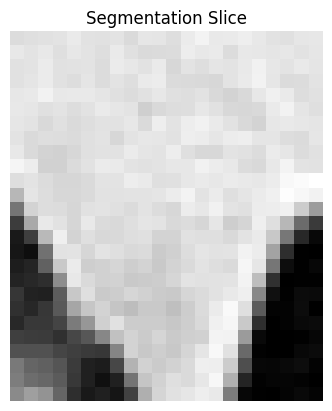

In [71]:
plt.imshow(all_imgs[130], cmap='gray')
plt.title("Segmentation Slice")
plt.axis('off')
plt.show()

In [ ]:
path_df = path_df.drop(columns='Histology')
path_df = path_df.merge(clinical_df[['PatientID', 'Overall.Stage']])

In [ ]:
path_df.head()

In [ ]:
#test train split
###### todo: once xgboost is finished, make sure to copy the exact test/train split from there #######

path_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/deeplearning_path.csv'))
clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
path_to_save = os.path.expanduser('~/project/xAI-in-NSCLC')


#Testing code with first 40 images only.

#patients = clinical_df.PatientID.unique()

#path_df = path_df.loc[path_df.PatientID.isin(patients)]
path_df = path_df.groupby(by='PatientID', as_index=False).sample(n=1, replace=True)
#clinical_df = clinical_df.loc[clinical_df.PatientID.isin(patients)]

#path_df = path_df.merge(clinical_df[['PatientID', 'Histology']], on='PatientID')


# test train split by patient ID
#temp_df = clinical_df.dropna(subset=['Histology'])
X = path_df
y = path_df['Histology']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=204, stratify=y)

# save patient IDs for deep learning test train split later
#train_labels = X_train.unique()
#test_labels = X_test.unique()


# create test train split dfs for training
#X_train = path_df.loc[path_df['PatientID'].isin(train_labels)]
#y_train = X_train['Histology']
#X_test = path_df.loc[path_df['PatientID'].isin(test_labels)]
#y_test = X_test['Histology']

X_train = X_train.drop(columns=['PatientID', 'Histology'])
X_test = X_test.drop(columns=['PatientID', 'Histology'])


In [ ]:
# base_dir = '/content/drive/MyDrive/PET-CTDICOMWholeDataset'

# training_set_dir = os.path.join(base_dir, 'trainingSet')
# test_set_dir = os.path.join(base_dir, 'testSet')

# train_lungCancer_dir = os.path.join(training_set_dir, 'lungCancer')
# train_normal_dir = os.path.join(training_set_dir, 'normal')
# test_lungCancer_dir = os.path.join(test_set_dir, 'lungCancer')
# test_normal_dir = os.path.join(test_set_dir, 'normal')

In [ ]:
# mapping mapping = {'adenocarcinoma': 0, 'squamous cell carcinoma': 1, 'large cell': 2, 'nos':3 }

print('TRAINING SET DISTRIBUTION: -------------------')
print(f'\nAdenocarcinoma: {len(y_train.loc[y_train == 0])} images ({(len(y_train.loc[y_train == 0])/len(y_train))*100:.1f}%)')
print(f'Squamous cell: {len(y_train.loc[y_train == 1])} images ({(len(y_train.loc[y_train == 1])/len(y_train))*100:.1f}%)')
print(f'Large cell: {len(y_train.loc[y_train == 2])} images ({(len(y_train.loc[y_train == 2])/len(y_train))*100:.1f}%)')
print(f'Not otherwise specified:: {len(y_train.loc[y_train == 3])} images ({(len(y_train.loc[y_train == 3])/len(y_train))*100:.1f}%)')

print('\nTESTING SET DISTRIBUTION: --------------------')
print(f'\nAdenocarcinoma: {len(y_test.loc[y_test == 0])} images ({(len(y_test.loc[y_test == 0])/len(y_test))*100:.1f}%)')
print(f'Squamous cell: {len(y_test.loc[y_test == 1])} images ({(len(y_test.loc[y_test == 1])/len(y_test))*100:.1f}%)')
print(f'Large cell: {len(y_test.loc[y_test == 2])} images ({(len(y_test.loc[y_test == 2])/len(y_test))*100:.1f}%)')
print(f'Not otherwise specified:: {len(y_test.loc[y_test == 3])} images ({(len(y_test.loc[y_test == 3])/len(y_train))*100:.1f}%)')

In [ ]:
#Converting to onehot encoding

y_train = tf.keras.ops.one_hot(
    y_train, 3, axis=-1, dtype=None, sparse=False
)
y_test = tf.keras.ops.one_hot(
    y_test, 3, axis=-1, dtype=None, sparse=False
)

#**Checking patient overlap**

In [ ]:
def check_data_leakage(directory1, directory2):
    filenames_dir1 = directory1.values
    filenames_dir2 = directory2.values

    common_filenames = [f for f in filenames_dir2 if f in filenames_dir1]

    if len(common_filenames) > 0:
        print("Data leakage detected!")
        print("Common image filenames between the directories:", common_filenames)
    else:
        print("No data leakage detected.")

In [ ]:
check_data_leakage(X_train, X_test)

##**Data generation**

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

def load_and_preprocess_dicom(dcm_path):
    dcm_data = pydicom.dcmread(dcm_path)
    image_data = dcm_data.pixel_array
    # images have dimensions 512 x 512
    # INput size of model should be 299 x 299, [80:392 ,90:422] would be 312 x 332
    # Note: it's like this vertical:[top, bottom], [? ?]
    cropped_image_data = image_data[106:405 ,107:406] #This is 299 x299

    # Could still be improved? Sometimes the image shows the table, sometimes is shifted largely left or right..
    return cropped_image_data

In [ ]:
train_image_labels = X_train.loc[X_train['path'].str.endswith('.dcm'), 'path'].tolist()
train_images = np.array([load_and_preprocess_dicom(file)for file in train_image_labels])

test_image_labels = X_test.loc[X_test['path'].str.endswith('.dcm'), 'path'].tolist()
test_images = np.array([load_and_preprocess_dicom(file)for file in test_image_labels])

In [ ]:
#Converting greyscale to rgb, InceptionV3 requires 3 channel input

print(f'Training set dimensions before: {train_images.shape}')
# img = img_array[0, :, :, 0]          # grayscale
# img_norm = (img - img.min()) / (img.max() - img.min())  # scale to 0–1
# img_rgb = np.stack([img_norm]*3, axis=-1)
# Fit on training set
train_min = train_images.min()
train_max = train_images.max()

# Apply to all sets
X_train = (train_images - train_min) / (train_max - train_min)
X_test  = (test_images  - train_min) / (train_max - train_min)

train_images = np.repeat(train_images[..., np.newaxis], 3, -1)

print(f'Training set dimensions after: {train_images.shape}')

print(f'\nTesting set dimensions before: {test_images.shape}')
test_images = np.repeat(test_images[..., np.newaxis], 3, -1)
print(f'Testing set dimensions after: {test_images.shape}')

In [ ]:
# You simply need to do this before showing in matplotlib, to return to greyscale values.
train_images[250][:, :, 1].shape

In [ ]:
plt.imshow(train_images[250][:, :, 1], cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# train_images = np.array([load_and_preprocess_dicom(os.path.join(train_lungCancer_dir, filename)) for filename in os.listdir(train_lungCancer_dir) if filename.endswith('.dcm')])
# train_images = np.array([load_and_preprocess_dicom()])
# train_labels = np.array([1] * len(train_images))

# normal_train_images = np.array([load_and_preprocess_dicom(os.path.join(train_normal_dir, filename)) for filename in os.listdir(train_normal_dir) if filename.endswith('.dcm')])
# normal_train_labels = np.array([0] * len(normal_train_images))

# train_images = np.concatenate((train_images, normal_train_images))
# train_labels = np.concatenate((train_labels, normal_train_labels))

train_generator = train_datagen.flow(train_images, y_train,
        batch_size=80,
        shuffle = True)

# test_images = np.array([load_and_preprocess_dicom(os.path.join(test_lungCancer_dir, filename)) for filename in os.listdir(test_lungCancer_dir) if filename.endswith('.dcm')])
# test_labels = np.array([1] * len(test_images))

# normal_test_images = np.array([load_and_preprocess_dicom(os.path.join(test_normal_dir, filename)) for filename in os.listdir(test_normal_dir) if filename.endswith('.dcm')])
# normal_test_labels = np.array([0] * len(normal_test_images))

# test_images = np.concatenate((test_images, normal_test_images))
# test_labels = np.concatenate((test_labels, normal_test_labels))

In [ ]:
print(test_images[100].shape)
print(train_images[100].shape)

#**Defining InceptionV3 model**

In [ ]:
pre_trained_model1 = InceptionV3(include_top=False,
                                        weights= 'imagenet',
                                        input_shape = (299, 299, 3)) #Could I specify input size here?

for layer in pre_trained_model1.layers:
  layer.trainable = False

In [ ]:
#pre_trained_model1.summary()

In [ ]:
last_layer1 = pre_trained_model1.get_layer('mixed10')
print(f'last layer output shape: {last_layer1.output.shape}')
last_output1 = last_layer1.output

x = layers.Flatten()(last_output1)
x = layers.Dense(2048, activation='relu')(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(4, activation='softmax')(x) # originally: x = layers.Dense(1)(x)
# x = layers.Activation(tf.nn.sigmoid)(x)



model1 = Model(pre_trained_model1.input, x)

In [ ]:
#model1.summary()

In [ ]:
savingPath = os.path.expanduser('~/project/xAI-in-NSCLC/deep-learning results/temporaryWeights.weights.h5')
checkpoint_path = os.path.expanduser('~/project/xAI-in-NSCLC/deep-learning results/Checkpoint_temporaryWeights.weights.h5')
checkpoint_dir = os.path.dirname(checkpoint_path)
print(checkpoint_path)
cp_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_weights_only=True, save_best_only=True, verbose= 1)

In [ ]:
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), loss='categorical_crossentropy', metrics=[tf.keras.metrics.CategoricalAccuracy(name='categorical_accuracy'),
                        tf.keras.metrics.Precision(name='Precision'),
                        tf.keras.metrics.Recall(name='Recall'),
                        tf.keras.metrics.TruePositives(name='TP'),
                        tf.keras.metrics.TrueNegatives(name='TN'),
                        tf.keras.metrics.FalseNegatives(name='FN'),
                        tf.keras.metrics.FalsePositives(name='FP'),
                        tf.keras.metrics.AUC(name='AUC')])

In [ ]:
history = model1.fit(train_generator, epochs=20, validation_data=(test_images, y_test),
            verbose = 2,
            callbacks = [cp_callback])

In [ ]:
# Extract loss values

# yeahhh I'm not sure whether this iwll imporve that much... Maybe subsample only a few patients per sample for the full dataset? Like 4 slices?
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Log Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.xticks(epochs, 2)  # force integer ticks
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
path_df.head()

In [ ]:
#Load the model

model1 = Model(pre_trained_model1.input, x)
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), loss='categorical_crossentropy', metrics=[tf.keras.metrics.CategoricalAccuracy(name='categorical_accuracy'),
                        tf.keras.metrics.Precision(name='Precision'),
                        tf.keras.metrics.Recall(name='Recall'),
                        tf.keras.metrics.TruePositives(name='TP'),
                        tf.keras.metrics.TrueNegatives(name='TN'),
                        tf.keras.metrics.FalseNegatives(name='FN'),
                        tf.keras.metrics.FalsePositives(name='FP'),
                        tf.keras.metrics.AUC(name='AUC')])

model1.load_weights(checkpoint_path)

In [ ]:
# Load your trained model
loaded_model = model1

output_directory = '/home/coder/project/xAI-in-NSCLC'

patient = path_df.loc[path_df['PatientID'] == 'LUNG1-001']
fileNames = patient.path
print(fileNames)


In [ ]:
from IPython.display import Image, display
import matplotlib as mpl
import matplotlib.pyplot as plt

In [ ]:
def get_img_array(img_path, size):
    img_resized = load_and_preprocess_dicom(fn)

    #img = io.imread(fn)
    #img_resized = resize(img, (image_height, image_width), anti_aliasing=True) 
    img_array = None

    img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
    img_array = np.repeat(img_array[...], 3, -1)
    #img = keras.utils.load_img(img_path, target_size=size)
    # `array` is a float32 Numpy array of shape (299, 299, 3)
    #array = keras.utils.img_to_array(img)
    # We add a dimension to transform our array into a "batch"
    # of size (1, 299, 299, 3)
    array = np.expand_dims(img_array, axis=0)
    return array


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [ ]:
img_size = (299, 299)
preprocess_input = keras.applications.xception.preprocess_input
decode_predictions = keras.applications.xception.decode_predictions

last_conv_layer_name = "conv2d_93"

# The local path to our target image
# img_path = keras.utils.get_file(
#     "african_elephant.jpg", "https://i.imgur.com/Bvro0YD.png"
# )

#display(Image(img_path))


In [ ]:
import matplotlib.cm as cm

In [ ]:
heatmap = make_gradcam_heatmap(img_array, model1, last_conv_layer_name)

# Normalize heatmap
heatmap = np.maximum(heatmap, 0)
heatmap /= heatmap.max()

# Convert to RGB
colormap = cm.get_cmap("jet")
heatmap_rgb = colormap(heatmap)[:, :, :3]

# Resize to match CT image
heatmap_rgb = cv2.resize(heatmap_rgb, (img_array.shape[2], img_array.shape[1]))
img = img_array[0, :, :, 0]          # grayscale
img_norm = (img - img.min()) / (img.max() - img.min())  # scale to 0–1
img_rgb = np.stack([img_norm]*3, axis=-1)                # make 3 channels

# Blend heatmap with original image
overlay = heatmap_rgb * 0.4 + img_rgb  # adjust alpha here

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_rgb, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Original Image')

axes[1].imshow(overlay)
axes[1].axis('off')
axes[1].set_title('Grad-CAM Overlay')

plt.show()

In [ ]:
filePaths = []

base_path = '/home/coder/project/xAI-in-NSCLC'
# for i in fileNames:
#     full_path = os.path.join(base_path, fn)
#     filePaths.append(new_path)
for fn in fileNames:
    full_path = os.path.join(base_path, fn)

    if full_path.endswith(".dcm"):
        filePaths.append(full_path)

for fn in filePaths:
    if fn.endswith(".dcm"):
        class_names = ["ClassA", "ClassB", "ClassC", "ClassD"]

        img_array = get_img_array(fn, img_size)
        preds = model1.predict(img_array)

        pred_idx = np.argmax(preds)
        pred_class = class_names[pred_idx]
        pred_prob = preds[0][pred_idx]

        print(f"Predicted: {pred_class} with probability {pred_prob:.4f}")

        heatmap = make_gradcam_heatmap(img_array, model1, last_conv_layer_name)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_array[0, :, :, 0], cmap='grey')
        axes[0].axis('off')
        axes[0].set_title('Original Image')
        axes[1].imshow(img_array[0, :, :, 0], cmap='grey')
        axes[1].imshow(heatmap, alpha=0.5)
        axes[1].axis('off')
        axes[1].set_title('Class Activation Map')
        plt.show()

        #filename = fn.split('/')[-1].split('.')[0]  
        #save_path = f"{output_directory}{filename}_heatmap.png"

        #fig.savefig(save_path, dpi=600, bbox_inches='tight')
        #plt.close(fig) 
        

In [ ]:
# Print what the top predicted class is
preds = model1.predict(img_array)
print("Predicted:", decode_predictions(preds, top=1)[0])

# Generate class activation heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

# Display heatmap
plt.matshow(heatmap)
plt.show()

In [ ]:


# test_images = np.array([load_and_preprocess_dicom(file)for file in test_image_labels])

In [ ]:
filePaths = []

base_path = '/home/coder/project/xAI-in-NSCLC'
# for i in fileNames:
#     full_path = os.path.join(base_path, fn)
#     filePaths.append(new_path)
for fn in fileNames:
    full_path = os.path.join(base_path, fn)

    if full_path.endswith(".dcm"):
        filePaths.append(full_path)

for fn in filePaths:
    if fn.endswith(".dcm"):
        img_resized = load_and_preprocess_dicom(fn)

        #img = io.imread(fn)
        #img_resized = resize(img, (image_height, image_width), anti_aliasing=True) 
        img_array = None

        img_array = tf.keras.preprocessing.image.img_to_array(img_resized)
        img_array = np.repeat(img_array[...], 3, -1)
        print(img_array.shape)
        # if img_array.ndim == 2:  # shape (H, W)
        #     img_array = np.stack([img_array]*3, axis=-1)

        # elif img_array.shape[-1] == 1:  # shape (H, W, 1)
        #     img_array = np.repeat(img_array, 3, axis=-1)
        img_tensor = np.expand_dims(img_array, axis=0)
        print(img_tensor.shape)

        predictions = loaded_model.predict(img_tensor)
        label_index = np.argmax(predictions)

        class_weights = loaded_model.layers[-1].get_weights()[0]
        class_weights_winner = class_weights[:, label_index]
        # final_conv_layer = loaded_model.get_layer("mixed10")
        final_conv_layer = loaded_model.get_layer("conv2d_93") #is this the last convolutional layer of the model?
    


        # get_output = K.function([loaded_model.layers[0].input], [final_conv_layer.output, loaded_model.layers[-1].output])
        # [conv_outputs, predictions] = get_output([img_tensor])
        # conv_outputs = np.squeeze(conv_outputs)

        grad_model = tf.keras.models.Model([loaded_model.inputs], [final_conv_layer.output, loaded_model.output])

        conv_outputs, predictions = grad_model(img_tensor)
        print(conv_outputs.shape)
        conv_outputs = conv_outputs[0]   # remove only the batch dimension

        #target_size = final_conv_layer.output.shape[1:3]  
        target_size = conv_outputs.shape[:2]
        print(tuple(target_size))
        mat_for_mult = scipy.ndimage.zoom(conv_outputs, (target_size[0] / conv_outputs.shape[0], target_size[1] / conv_outputs.shape[1], 1), order=1)

        cam = np.dot(mat_for_mult.reshape((-1, conv_outputs.shape[-1])), class_weights_winner).reshape(target_size)
        cam = (cam - cam.min()) / (cam.max() - cam.min())

        cam_resized = resize(cam, img_resized.shape[:2], mode='reflect', anti_aliasing=True)

        heatmap = plt.cm.jet(cam_resized)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_resized)
        axes[0].axis('off')
        axes[0].set_title('Original Image')
        axes[1].imshow(img_resized)
        axes[1].imshow(heatmap, alpha=0.5)
        axes[1].axis('off')
        axes[1].set_title('Class Activation Map')
        plt.show()

        #filename = fn.split('/')[-1].split('.')[0]  
        #save_path = f"{output_directory}{filename}_heatmap.png"

        #fig.savefig(save_path, dpi=600, bbox_inches='tight')
        #plt.close(fig)  

In [ ]:
# for layer in model1.layers[::-1]:
#     if isinstance(layer, tf.keras.layers.Conv2D):
#         print("Last conv layer:", layer.name)
#         break

last_conv = None
for layer in model1.layers[::-1]:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer
        break

print("Detected last conv layer:", last_conv.name)


In [ ]:
model1.summary()